In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/DeepLearningFruitProject"

print(os.path.exists(project_path))

True


# Deep Learning Unit Project #

## FRUIT CLASSIFICATION USING CONVOLUTIONAL NEURAL NETWORKS ##

### Tara Simiyu Khatembula ###
### 24/04811 ###

This project aims to develop a deep learning-based image classification system capable of identifying multiple fruit categories using Convolutional Neural Networks (CNNs). The system will be implemented using TensorFlow and Keras and evaluated using accuracy, precision, recall, F1-score, and confusion matrix metrics.

# Part I: Dataset Acquisition and Preparation

## Objective
To obtain a fruit image dataset and prepare it for deep learning model training, validation, and testing.

## Dataset Source
Kaggle Fruit Classification Dataset

# Dataset Selection
Five fruit categories were selected for the classification task:

1.Apple

2.Banana

3.Mango

4.Grape

5.Pineapple

The original dataset contained 101 fruit categories. To simplify the classification task and reduce computational requirements, only five classes were retained for model deployment.

These classes were chosen because they are well represented in the dataset and visually distinct, making them suitable for image classification using CNNs.



## Loading the Dataset

The prepared dataset is loaded from Google Drive for inspection and subsequent preprocessing.

In [ ]:
import os

train_dir = "/content/drive/MyDrive/DeepLearningFruitProject/dataset/train"
val_dir = "/content/drive/MyDrive/DeepLearningFruitProject/dataset/val"

print("Training classes:")
print(os.listdir(train_dir))

print("\nValidation classes:")
print(os.listdir(val_dir))

Training classes:
['banana', 'apple', 'grape', 'mango', 'pineapple']

Validation classes:
['pineapple', 'mango', 'grape', 'banana', 'apple']


Count images per class

In [ ]:
for fruit in os.listdir(train_dir):
    train_count = len(os.listdir(os.path.join(train_dir, fruit)))
    val_count = len(os.listdir(os.path.join(val_dir, fruit)))

    print(f"{fruit}")
    print(f"  Training Images: {train_count}")
    print(f"  Validation Images: {val_count}")
    print()

banana
  Training Images: 416
  Validation Images: 50

apple
  Training Images: 400
  Validation Images: 50

grape
  Training Images: 400
  Validation Images: 50

mango
  Training Images: 416
  Validation Images: 50

pineapple
  Training Images: 400
  Validation Images: 50



## Displaying Sample Images

Sample images from each fruit class are displayed to verify dataset quality and class diversity.


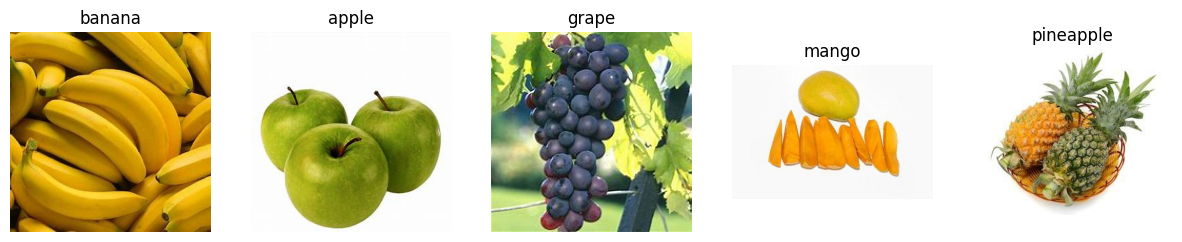

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

classes = os.listdir(train_dir)

plt.figure(figsize=(15,5))

for i, fruit in enumerate(classes):
    fruit_folder = os.path.join(train_dir, fruit)

    image_name = os.listdir(fruit_folder)[0]
    image_path = os.path.join(fruit_folder, image_name)

    img = mpimg.imread(image_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(fruit)
    plt.axis("off")

plt.show()

# Part II : Data Preprocessing

## Objective

The dataset is preprocessed to ensure consistency and improve model performance.Images are loaded, resized, normalized, and augmented before being used for CNN training.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Load image datasets

In [ ]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 2032 files belonging to 5 classes.
Found 250 files belonging to 5 classes.


## Dataset Inspection

The loaded dataset is inspected to verify image dimensions, labels, and class names before preprocessing.

In [ ]:
class_names = train_ds.class_names

print("Class Names:")
print(class_names)

Class Names:
['apple', 'banana', 'grape', 'mango', 'pineapple']


Inspect One Batch

In [ ]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 180, 180, 3)
Label Batch Shape: (32,)


Display a Batch of images

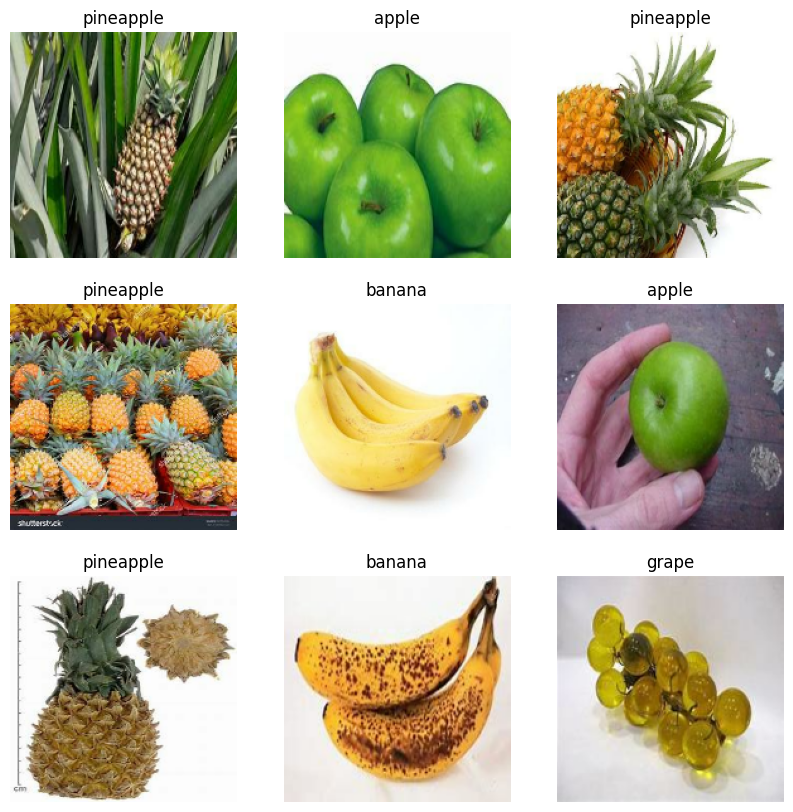

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Image Normalization

Pixel values are scaled from the range [0,255] to [0,1] to improve training stability and convergence.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
# Check normalization

for images, labels in train_ds.take(1):

    first_image = images[0]

    print("Before normalization")
    print("Minimum pixel value:", tf.reduce_min(first_image).numpy())
    print("Maximum pixel value:", tf.reduce_max(first_image).numpy())

    normalized_image = normalization_layer(first_image)

    print("\nAfter normalization")
    print("Minimum pixel value:", tf.reduce_min(normalized_image).numpy())
    print("Maximum pixel value:", tf.reduce_max(normalized_image).numpy())

Before normalization
Minimum pixel value: 0.0
Maximum pixel value: 255.0

After normalization
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Data Augmentation

Data augmentation techniques are applied to artificially increase dataset diversity and improve model generalization.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

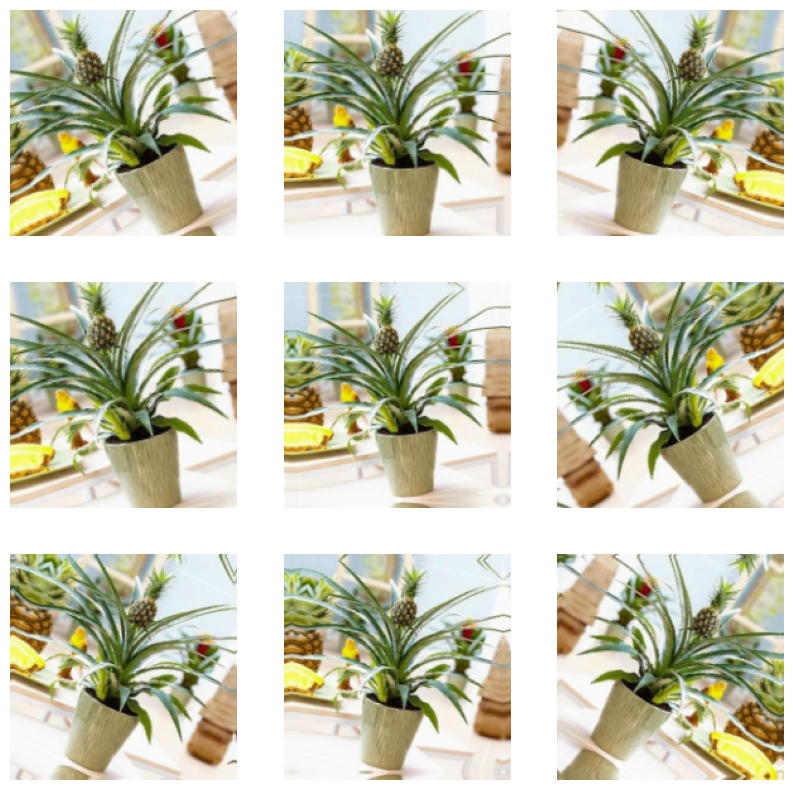

In [ ]:
# DISPLAY AUGMENTED IMAGES


plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    first_image = images[0]

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0)
        )

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.show()

# Part III: CNN Model Development

## Objective

A Convolutional Neural Network (CNN) is developed to classify fruit images into five categories: Apple, Banana, Grape, Mango, and Pineapple.

In [ ]:
# BASELINE CNN MODEL

num_classes = len(class_names)

model = keras.Sequential([

    layers.Rescaling(1./255,
                      input_shape=(180,180,3)),

    layers.Conv2D( #detects image features
        16,
        3,
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),# Reduces image size

    layers.Conv2D(
        32,
        3,
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),# converts feature maps into 1D vector

    layers.Dense( # Acts like the classifier
        128,
        activation='relu'
    ),

    layers.Dense(num_classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile model

In [ ]:
model.compile(

    optimizer='adam',#adjusts weights efficiently

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

# Part IV: Model Training and Evaluation

## Objective

The CNN model is trained using the prepared dataset and evaluated using classification performance metrics.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 331s 5s/step - accuracy: 0.3750 - loss: 1.4074 - val_accuracy: 0.5840 - val_loss: 1.1332
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5856 - loss: 1.0360 - val_accuracy: 0.6080 - val_loss: 0.9769
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6727 - loss: 0.8517 - val_accuracy: 0.6080 - val_loss: 0.9721
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7426 - loss: 0.7064 - val_accuracy: 0.6720 - val_loss: 0.9629
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8115 - loss: 0.5281 - val_accuracy: 0.6800 - val_loss: 0.9620
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8686 - loss: 0.3753 - val_accuracy: 0.6240 - val_loss: 1.2051
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9163 - loss: 0.2467 - val_accuracy: 0.6800 - val_loss: 1.2270
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9532 - loss: 0.1490 - val_accuracy: 0.6520 - val_loss

In [ ]:
#evaluate model

loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.6840 - loss: 1.5208
Validation Accuracy: 0.6840000152587891
Validation Loss: 1.5208230018615723


## Training Performance Visualization

Training and validation accuracy/loss curves were plotted to assess model learning behavior and detect overfitting.

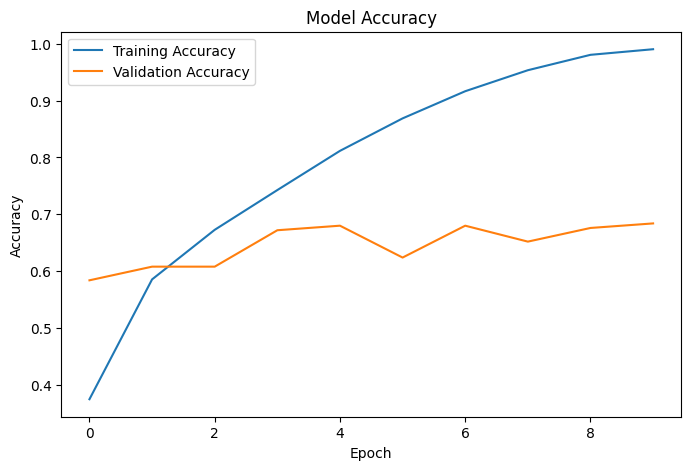

In [ ]:

# ACCURACY GRAPH

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

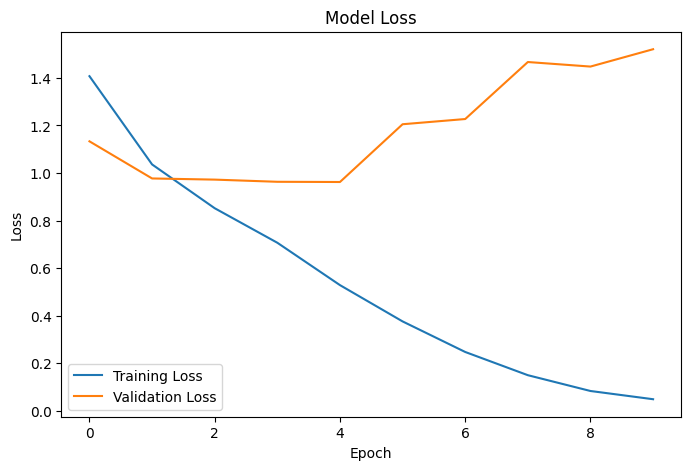

In [ ]:
# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

## Classification Metrics

The trained model is evaluated using precision, recall, F1-score, and confusion matrix to assess classification performance across all fruit classes.

In [ ]:
# GENERATE PREDICTIONS

import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
print(len(y_true))
print(len(y_pred))

250
250


Precision, Recall, F1-Score


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       apple       0.61      0.60      0.61        50
      banana       0.61      0.56      0.58        50
       grape       0.73      0.72      0.73        50
       mango       0.61      0.70      0.65        50
   pineapple       0.86      0.84      0.85        50

    accuracy                           0.68       250
   macro avg       0.69      0.68      0.68       250
weighted avg       0.69      0.68      0.68       250



Confusion Matrix


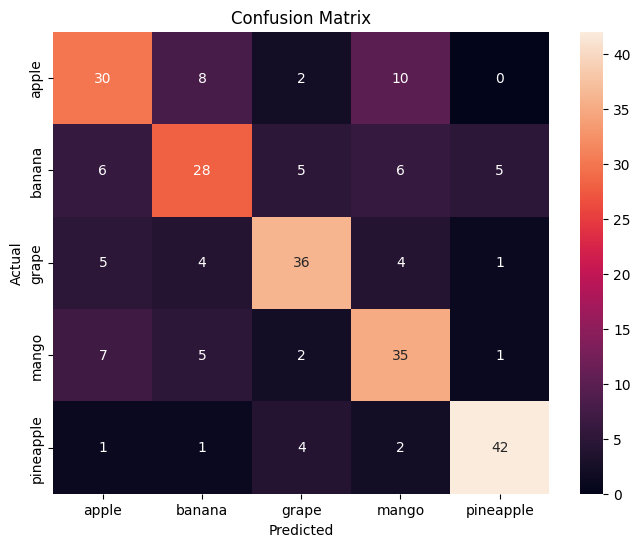

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(cm)

[[30  8  2 10  0]
 [ 6 28  5  6  5]
 [ 5  4 36  4  1]
 [ 7  5  2 35  1]
 [ 1  1  4  2 42]]


# Part V: Model Optimization

## Objective

Several optimization techniques were applied to improve model generalization and reduce overfitting. These included data augmentation, batch normalization, dropout regularization, and early stopping.

Optimized CNN Model


In [ ]:
optimized_model = keras.Sequential([

    layers.Rescaling(1./255,
                      input_shape=(180,180,3)),

    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(num_classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile optimized model

In [ ]:
optimized_model.compile(

    optimizer='adam',

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=['accuracy']
)

Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# PERFORMANCE OPTIMIZATION

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Training the Optimized CNN

The optimized CNN was trained using batch normalization, dropout regularization, data augmentation, and early stopping to improve generalization performance.

In [ ]:
optimized_history = optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.3425 - loss: 3.9664 - val_accuracy: 0.2000 - val_loss: 16.0140
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.4208 - loss: 1.3870 - val_accuracy: 0.2480 - val_loss: 6.8143
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.4528 - loss: 1.3233 - val_accuracy: 0.2440 - val_loss: 7.0009
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.4783 - loss: 1.2145 - val_accuracy: 0.3080 - val_loss: 8.0863
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.4902 - loss: 1.1902 - val_accuracy: 0.4360 - val_loss: 1.7699
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.5108 - loss: 1.1389 - val_accuracy: 0.4920 - val_loss: 1.8808
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5512 - loss: 1.0552 - val_accuracy: 0.4600 - val_loss: 3.4299
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.5458 - loss: 1.0514 - val_accuracy: 0.6080 - 

In [ ]:
loss, accuracy = optimized_model.evaluate(val_ds)

print("Optimized Validation Accuracy:", accuracy)
print("Optimized Validation Loss:", loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step - accuracy: 0.6320 - loss: 0.9212
Optimized Validation Accuracy: 0.6320000290870667
Optimized Validation Loss: 0.921168327331543


## Enhanced CNN Optimization

A deeper CNN architecture was developed to improve feature extraction while retaining batch normalization, dropout regularization, and early stopping.

In [ ]:
# ==========================================
# ENHANCED OPTIMIZED CNN
# ==========================================

optimized_model_v2 = keras.Sequential([

    layers.Rescaling(1./255,
                     input_shape=(180,180,3)),

    layers.Conv2D(
        32,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(num_classes)
])

In [ ]:
optimized_model_v2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
optimized_history_v2 = optimized_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 0.3194 - loss: 4.4933 - val_accuracy: 0.2000 - val_loss: 17.8818
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.3273 - loss: 1.5088 - val_accuracy: 0.2800 - val_loss: 10.8142
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.3720 - loss: 1.4376 - val_accuracy: 0.3200 - val_loss: 9.9548
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.3755 - loss: 1.3836 - val_accuracy: 0.2640 - val_loss: 4.7924
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.3671 - loss: 1.3859 - val_accuracy: 0.3320 - val_loss: 6.8006
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.4183 - loss: 1.3055 - val_accuracy: 0.3240 - val_loss: 3.2913
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.4503 - loss: 1.2129 - val_accuracy: 0.4920 - val_loss: 1.8177
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.4444 - loss: 1.1941 - val_accuracy: 0.4360 -

# Transfer Learning Using MobileNetV2

To improve classification performance, transfer learning was applied using the pre-trained MobileNetV2 architecture.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
num_classes = len(class_names)

transfer_model = models.Sequential([

    layers.Resizing(224,224),

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(num_classes)
])

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
print(class_names)

['apple', 'banana', 'grape', 'mango', 'pineapple']


In [ ]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8327 - loss: 0.4321 - val_accuracy: 0.9040 - val_loss: 0.2621
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9390 - loss: 0.1628 - val_accuracy: 0.9280 - val_loss: 0.2086
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9631 - loss: 0.1022 - val_accuracy: 0.9120 - val_loss: 0.2258
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9759 - loss: 0.0735 - val_accuracy: 0.9280 - val_loss: 0.2186
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9847 - loss: 0.0509 - val_accuracy: 0.9360 - val_loss: 0.2065
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9847 - loss: 0.0440 - val_accuracy: 0.9400 - val_loss: 0.2204
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9902 - loss: 0.0327 - val_accuracy: 0.9200 - val_loss: 0.2304
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9956 - loss: 0.0184 - val_accuracy: 0.9320 - v

In [ ]:
loss, accuracy = transfer_model.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9360 - loss: 0.2065
Transfer Learning Accuracy: 0.9359999895095825
Transfer Learning Loss: 0.20651809871196747


Generating predictions

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = transfer_model.predict(images, verbose=0)

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Done!")

Done!


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       apple       0.85      0.88      0.86        50
      banana       1.00      0.96      0.98        50
       grape       0.98      0.98      0.98        50
       mango       0.88      0.86      0.87        50
   pineapple       0.98      1.00      0.99        50

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



Confusion Matrix

[[44  0  0  6  0]
 [ 0 48  1  0  1]
 [ 1  0 49  0  0]
 [ 7  0  0 43  0]
 [ 0  0  0  0 50]]


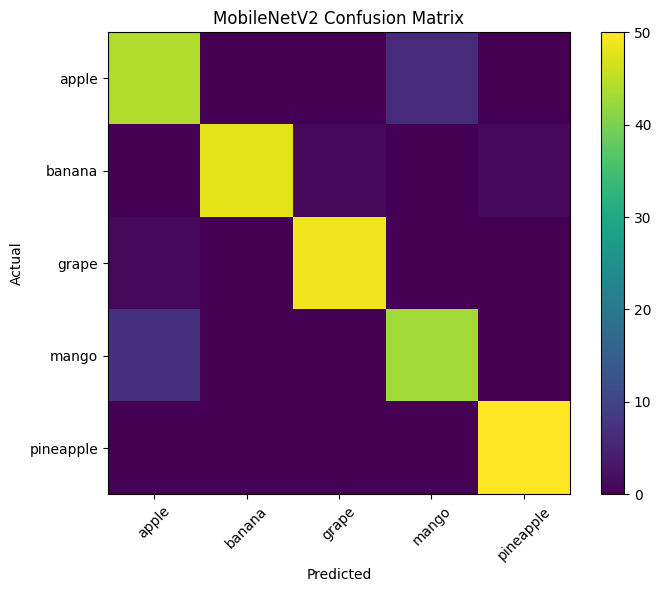

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

# Part VI: Testing with Unseen Images

The final MobileNetV2 model was tested on five unseen fruit images that were not included in the training or validation datasets.

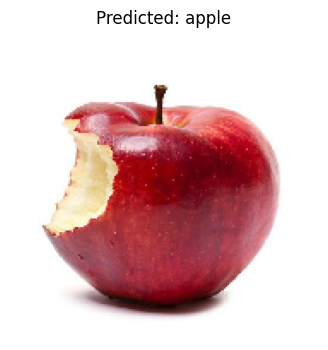

apple_test.jpg -> apple


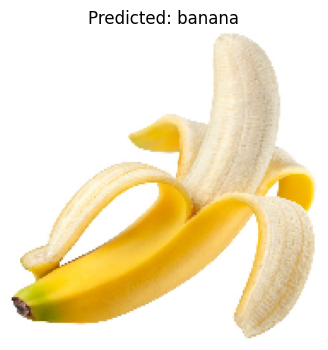

banana_test.jpg -> banana


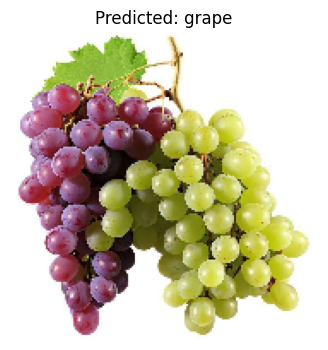

grape_test.jpg -> grape


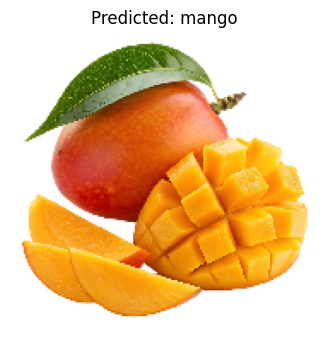

mango_test.jpg -> mango


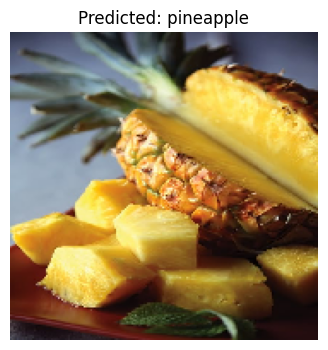

pineapple_test.jpg -> pineapple


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

test_folder = "/content/drive/MyDrive/DeepLearningFruitProject/test_images"

for image_name in os.listdir(test_folder):

    image_path = os.path.join(test_folder, image_name)

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(180,180)
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = tf.expand_dims(img_array, 0)

    prediction = transfer_model.predict(
        img_array,
        verbose=0
    )

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class}"
    )
    plt.show()

    print(
        f"{image_name} -> {predicted_class}"
    )

# Part VII: Model Saving and Deployment

The final MobileNetV2 model was saved for future use and deployment. TensorFlow Lite conversion was also performed to support deployment on lightweight environments.

In [ ]:
transfer_model.save("fruit_classifier_mobilenet.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.getsize("fruit_classifier_mobilenet.h5")/(1024*1024), "MB")

10.855018615722656 MB


Converting to Tensorflow Lite





In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    transfer_model
)

tflite_model = converter.convert()

with open(
    "fruit_classifier_mobilenet.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")

Saved artifact at '/tmp/tmp_6d6jwiu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor_360')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137170426455120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426458576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426458384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426457808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426459152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426457040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426458768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426458960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426458000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137170426460112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1371704264

In [ ]:
import os

print(
    os.path.getsize(
        "fruit_classifier_mobilenet.tflite"
    )/(1024*1024),
    "MB"
)

9.077537536621094 MB
